# Fast vs Original Backend Comparison — Perturb-seq Analysis

This notebook runs the same Perturb-seq analysis pipeline using both the **original statsmodels backend** and the **new crispyx fast backend**, and compares:
1. **Wall-clock time** for each stage (dispersion estimation, GCATE, LFC)
2. **Result agreement** (coefficient correlation, LFC correlation, discovery overlap)

In [1]:
import sys
print(sys.executable)
print(sys.version)

/Users/dujinhong/miniforge3/envs/causarray/bin/python
3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:59:46) [Clang 19.1.7 ]


In [2]:
import os

import sys
sys.path.insert(0, '../../..')

import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc

from causarray import prep_causarray_data, fit_gcate, LFC
import causarray.gcate_glm as gcate_glm

print(f"crispyx available: {gcate_glm._HAS_CRISPYX}")
print(f"causarray version: {__import__('causarray').__version__}")

crispyx available: True
causarray version: 0.0.6


## Load and prepare data

In [3]:
adata = sc.read_h5ad('perturbseq-exneu.h5ad')
print(adata)

Y = pd.DataFrame(adata.X.copy(), columns=adata.var.index)
A = pd.get_dummies(adata.obs['Perturbation'], columns=['Perturbation'], drop_first=False).drop(columns=['GFP'])
Y, A, X, X_A = prep_causarray_data(Y, A)

print(f"\nY: {Y.shape} (n_cells x n_genes)")
print(f"A: {A.shape} (n_cells x n_perturbations)")
print(f"X: {X.shape}, X_A: {X_A.shape}")
print(f"n_genes = {Y.shape[1]} (>= 50 threshold for fast backend)")

AnnData object with n_obs × n_vars = 2926 × 3221
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'nGene', 'nUMI', 'Cluster', 'Batch', 'CellType', 'Perturbation', 'isKey', 'isAnalysed', 'SCRUBLET'

Y: (2926, 3221) (n_cells x n_genes)
A: (2926, 29) (n_cells x n_perturbations)
X: (2926, 1), X_A: (2926, 2)
n_genes = 3221 (>= 50 threshold for fast backend)


## 1. Run with the original statsmodels backend (baseline)

In [4]:
# Force statsmodels backend
gcate_glm._HAS_CRISPYX = False
r = 10

t0 = time.time()
res_1_orig, res_2_orig = fit_gcate(Y, X, A, r, verbose=True)
t_gcate_orig = time.time() - t0
U_orig = res_2_orig['U']
print(f"\n[Original] GCATE time: {t_gcate_orig:.1f}s")

'Estimating dispersion parameter...'
'Fitting poisson GLM with offset...'


{'d': 30, 'n': 2926, 'p': 3221, 'r': 10}
'Estimating initial latent variables with GLMs...'
'Fitting nb GLM with offset...'



  0%|          | 0/3221 [00:00<?, ?it/s]


  2%|▏         | 60/3221 [00:00<00:06, 512.80it/s]


  4%|▎         | 120/3221 [00:00<00:05, 550.21it/s]

...


 11%|█         | 53/500 [00:48<06:12,  1.20it/s, nll=1.70]


 11%|█         | 54/500 [00:48<06:11,  1.20it/s, nll=1.70]


 11%|█         | 54/500 [00:49<06:11,  1.20it/s, Early stopped. Best Epoch: 48. Best Metric: 1.700308.]


 11%|█         | 54/500 [00:49<06:49,  1.09it/s, Early stopped. Best Epoch: 48. Best Metric: 1.700308.]


[Original] GCATE time: 140.0s


In [5]:
offsets_orig = np.log(res_2_orig['kwargs_glm']['size_factor'])

t0 = time.time()
df_orig, est_orig = LFC(Y, np.c_[X, U_orig], A, np.c_[X_A, U_orig], offset=offsets_orig, verbose=True)
t_lfc_orig = time.time() - t0
print(f"\n[Original] LFC time: {t_lfc_orig:.1f}s")
print(f"[Original] Total time: {t_gcate_orig + t_lfc_orig:.1f}s")
print(f"Discoveries (padj < 0.1): {(df_orig['padj'] < 0.1).sum()}")

'Estimating LFC...'
{'a': 29, 'd': 11, 'd_A': 12, 'estimands': 'LFC', 'n': 2926, 'p': 3221}
{'C': 1.0,
 'class_weight': 'balanced',
 'fit_intercept': False,
 'random_state': 0,
 'verbose': False}
{'offset': array([-0.63123664, -0.13510128,  0.20175377, ..., -0.58092607,
       -0.31435661, -0.25029351], shape=(2926,)),
 'random_state': 0,
 'verbose': True}
'Fit propensity score models...'
'Fit outcome models...'
'Estimating dispersion parameter...'
'Fitting poisson GLM with offset...'


'Fitting nb GLM with offset...'



  0%|          | 0/3221 [00:00<?, ?it/s]


  2%|▏         | 60/3221 [00:00<00:06, 462.12it/s]


  4%|▎         | 120/3221 [00:00<00:15, 204.36it/s]

...


 83%|████████▎ | 24/29 [00:01<00:00, 14.44it/s]


 90%|████████▉ | 26/29 [00:01<00:00, 14.75it/s]


 97%|█████████▋| 28/29 [00:02<00:00, 13.81it/s]


100%|██████████| 29/29 [00:02<00:00, 13.75it/s]


[Original] LFC time: 87.5s
[Original] Total time: 227.5s
Discoveries (padj < 0.1): 18245


## 2. Run with the crispyx fast backend

In [6]:
# Enable crispyx fast backend
gcate_glm._HAS_CRISPYX = True
print(f"crispyx available: {gcate_glm._HAS_CRISPYX}")

t0 = time.time()
res_1_fast, res_2_fast = fit_gcate(Y, X, A, r, verbose=True)
t_gcate_fast = time.time() - t0
U_fast = res_2_fast['U']
print(f"\n[Fast] GCATE time: {t_gcate_fast:.1f}s")
print(f"GCATE speedup: {t_gcate_orig / t_gcate_fast:.1f}x")

crispyx available: True


{'d': 30, 'n': 2926, 'p': 3221, 'r': 10}
'Estimating initial latent variables with GLMs...'
'Fitting nb GLM with offset...'



  0%|          | 0/3221 [00:00<?, ?it/s]


  1%|          | 30/3221 [00:00<00:47, 67.10it/s]


  3%|▎         | 90/3221 [00:01<00:35, 89.18it/s]

...


  9%|▉         | 47/500 [00:31<04:58,  1.52it/s, nll=1.72]


 10%|▉         | 48/500 [00:31<04:57,  1.52it/s, nll=1.72]


 10%|▉         | 48/500 [00:32<04:57,  1.52it/s, Early stopped. Best Epoch: 42. Best Metric: 1.720517.]


 10%|▉         | 48/500 [00:32<05:01,  1.50it/s, Early stopped. Best Epoch: 42. Best Metric: 1.720517.]


[Fast] GCATE time: 120.3s
GCATE speedup: 1.2x


In [7]:
offsets_fast = np.log(res_2_fast['kwargs_glm']['size_factor'])

t0 = time.time()
df_fast, est_fast = LFC(Y, np.c_[X, U_fast], A, np.c_[X_A, U_fast], offset=offsets_fast, verbose=True)
t_lfc_fast = time.time() - t0
print(f"\n[Fast] LFC time: {t_lfc_fast:.1f}s")
print(f"[Fast] Total time: {t_gcate_fast + t_lfc_fast:.1f}s")
print(f"LFC speedup: {t_lfc_orig / t_lfc_fast:.1f}x")
print(f"Discoveries (padj < 0.1): {(df_fast['padj'] < 0.1).sum()}")

'Estimating LFC...'
{'a': 29, 'd': 11, 'd_A': 12, 'estimands': 'LFC', 'n': 2926, 'p': 3221}
{'C': 1.0,
 'class_weight': 'balanced',
 'fit_intercept': False,
 'random_state': 0,
 'verbose': False}
{'offset': array([-0.63123664, -0.13510128,  0.20175377, ..., -0.58092607,
       -0.31435661, -0.25029351], shape=(2926,)),
 'random_state': 0,
 'verbose': True}
'Fit propensity score models...'


'Fit outcome models...'


'Fitting nb GLM (fast)...'


'Estimating AIPW mean...'



  0%|          | 0/29 [00:00<?, ?it/s]

...


 83%|████████▎ | 24/29 [00:01<00:00, 14.99it/s]


 90%|████████▉ | 26/29 [00:01<00:00, 15.23it/s]


 97%|█████████▋| 28/29 [00:01<00:00, 14.24it/s]


100%|██████████| 29/29 [00:02<00:00, 14.36it/s]


[Fast] LFC time: 48.4s
[Fast] Total time: 168.7s
LFC speedup: 1.8x
Discoveries (padj < 0.1): 15477


## 3. Compare results

### 3.1 Timing summary

In [8]:
timing = pd.DataFrame({
    'Stage': ['GCATE', 'LFC', 'Total'],
    'Original (s)': [t_gcate_orig, t_lfc_orig, t_gcate_orig + t_lfc_orig],
    'Fast (s)': [t_gcate_fast, t_lfc_fast, t_gcate_fast + t_lfc_fast],
})
timing['Speedup'] = timing['Original (s)'] / timing['Fast (s)']
timing = timing.round(1)
print(timing.to_string(index=False))

Stage  Original (s)  Fast (s)  Speedup
GCATE         140.0     120.3      1.2
  LFC          87.5      48.4      1.8
Total         227.5     168.7      1.3


### 3.2 LFC correlation across perturbations

In [9]:
tau_orig = df_orig['tau'].values
tau_fast = df_fast['tau'].values

overall_corr = np.corrcoef(tau_orig, tau_fast)[0, 1]
print(f"Overall LFC correlation: {overall_corr:.4f}")

# Per-perturbation correlation
perturbations = df_orig['trt'].unique()
corrs = []
for p in perturbations:
    mask = df_orig['trt'] == p
    c = np.corrcoef(tau_orig[mask], tau_fast[mask])[0, 1]
    corrs.append({'Perturbation': p, 'LFC_corr': c})
df_corr = pd.DataFrame(corrs).sort_values('LFC_corr')
print(f"\nPer-perturbation LFC correlation:")
print(df_corr.to_string(index=False))

Overall LFC correlation: 0.8967

Per-perturbation LFC correlation:
Perturbation  LFC_corr
       Ddx3x  0.856516
      Tnrc6b  0.872810
      Ctnnb1  0.875084
        Pogz  0.876631
       Kdm5b  0.878002
       Satb2  0.879174
        Chd8  0.885297
       Asxl3  0.886563
      Med13l  0.887392
      Qrich1  0.887618
        Pten  0.889069
       Setd5  0.894192
        Spen  0.896970
       Dscam  0.899034
        Mll1  0.899145
        Cul3  0.899375
        Mbd5  0.901693
        Adnp  0.902677
      Stard9  0.907222
     Syngap1  0.907641
       Upf3b  0.910704
       Myst4  0.913089
      Scn2a1  0.914042
         Wac  0.914226
      Fbxo11  0.914650
       Setd2  0.920716
       Ash1l  0.924346
      Dyrk1a  0.930874
       Tcf20  0.937345


### 3.3 Discovery overlap

In [10]:
sig_orig = set(df_orig[df_orig['padj'] < 0.1].index)
sig_fast = set(df_fast[df_fast['padj'] < 0.1].index)

n_orig = len(sig_orig)
n_fast = len(sig_fast)
n_overlap = len(sig_orig & sig_fast)
jaccard = n_overlap / len(sig_orig | sig_fast) if len(sig_orig | sig_fast) > 0 else 0

print(f"Discoveries (padj < 0.1):")
print(f"  Original:  {n_orig}")
print(f"  Fast:      {n_fast}")
print(f"  Overlap:   {n_overlap}")
print(f"  Jaccard:   {jaccard:.3f}")
print(f"  Orig-only: {n_orig - n_overlap}")
print(f"  Fast-only: {n_fast - n_overlap}")

Discoveries (padj < 0.1):
  Original:  18245
  Fast:      15477
  Overlap:   14357
  Jaccard:   0.741
  Orig-only: 3888
  Fast-only: 1120


### 3.4 Scatter plots of LFC estimates

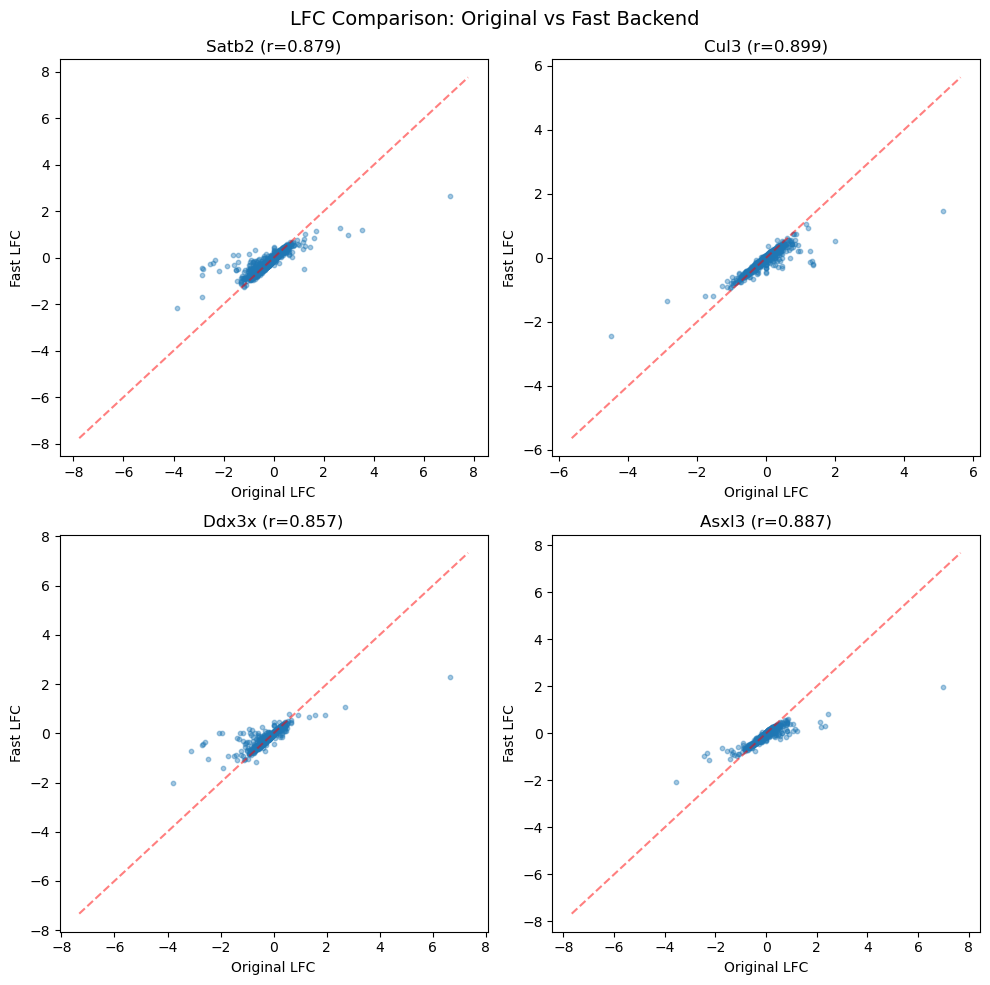

In [11]:
top_perts = df_orig.groupby('trt')['padj'].apply(lambda x: (x < 0.1).sum()).nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for idx, pert in enumerate(top_perts):
    ax = axes[idx // 2, idx % 2]
    mask = df_orig['trt'] == pert
    ax.scatter(tau_orig[mask], tau_fast[mask], alpha=0.4, s=10)
    lim = max(abs(tau_orig[mask]).max(), abs(tau_fast[mask]).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'r--', alpha=0.5)
    c = np.corrcoef(tau_orig[mask], tau_fast[mask])[0, 1]
    ax.set_title(f'{pert} (r={c:.3f})')
    ax.set_xlabel('Original LFC')
    ax.set_ylabel('Fast LFC')
fig.suptitle('LFC Comparison: Original vs Fast Backend', fontsize=14)
fig.tight_layout()
plt.show()

### 3.5 Per-perturbation discovery counts

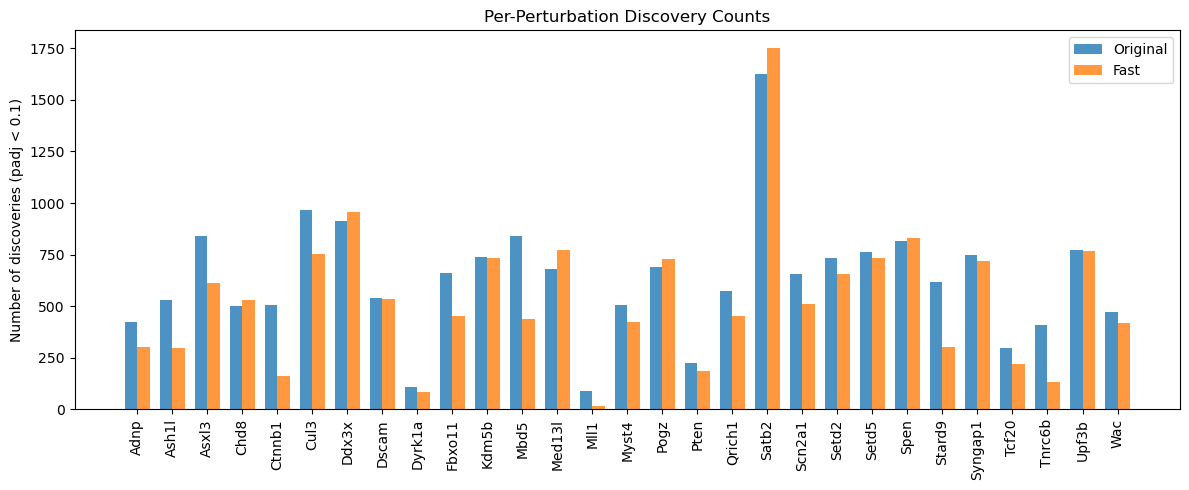

         Original  Fast  Diff
trt                          
Adnp          425   302  -123
Ash1l         532   295  -237
Asxl3         840   613  -227
Chd8          500   532    32
Ctnnb1        507   162  -345
Cul3          964   752  -212
Ddx3x         915   958    43
Dscam         542   534    -8
Dyrk1a        108    85   -23
Fbxo11        663   452  -211
Kdm5b         739   732    -7
Mbd5          838   440  -398
Med13l        682   773    91
Mll1           90    18   -72
Myst4         504   421   -83
Pogz          692   731    39
Pten          226   184   -42
Qrich1        572   451  -121
Satb2        1627  1750   123
Scn2a1        654   509  -145
Setd2         734   656   -78
Setd5         763   735   -28
Spen          815   830    15
Stard9        616   304  -312
Syngap1       750   720   -30
Tcf20         295   221   -74
Tnrc6b        408   131  -277
Upf3b         771   767    -4
Wac           473   419   -54


In [12]:
disc_orig = df_orig[df_orig['padj'] < 0.1].groupby('trt').size().rename('Original')
disc_fast = df_fast[df_fast['padj'] < 0.1].groupby('trt').size().rename('Fast')
df_disc = pd.concat([disc_orig, disc_fast], axis=1).fillna(0).astype(int)
df_disc['Diff'] = df_disc['Fast'] - df_disc['Original']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_disc))
w = 0.35
ax.bar(x - w/2, df_disc['Original'], w, label='Original', alpha=0.8)
ax.bar(x + w/2, df_disc['Fast'], w, label='Fast', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_disc.index, rotation=90)
ax.set_ylabel('Number of discoveries (padj < 0.1)')
ax.set_title('Per-Perturbation Discovery Counts')
ax.legend()
fig.tight_layout()
plt.show()

print(df_disc)

### 3.6 Latent factor comparison

Compare the estimated latent confounders (U) between the two backends.

In [13]:
# Canonical correlation between U_orig and U_fast
# (accounts for rotation/sign ambiguity in SVD-based factors)
from sklearn.cross_decomposition import CCA

n_components = min(r, U_orig.shape[1], U_fast.shape[1])
cca = CCA(n_components=n_components)
U_orig_c, U_fast_c = cca.fit_transform(U_orig, U_fast)
can_corrs = [np.corrcoef(U_orig_c[:, k], U_fast_c[:, k])[0, 1] for k in range(n_components)]

print("Canonical correlations between U_orig and U_fast:")
for k, c in enumerate(can_corrs):
    print(f"  Component {k+1}: {c:.4f}")
print(f"  Mean: {np.mean(can_corrs):.4f}")

Canonical correlations between U_orig and U_fast:
  Component 1: 0.9992
  Component 2: 0.9984
  Component 3: 0.9990
  Component 4: 0.9991
  Component 5: 0.9992
  Component 6: 0.9995
  Component 7: 0.9989
  Component 8: 0.9914
  Component 9: 0.9862
  Component 10: 0.9806
  Mean: 0.9952
